In [1]:
import mlgw_bns

/workspaces/mlgw_bns/mlgw_bns/model.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
from mlgw_bns import Model
model = Model.default()

In [3]:
from mlgw_bns import ParametersWithExtrinsic
import numpy as np 

frequencies = np.linspace(20., 2048., num=2000)
params = ParametersWithExtrinsic(
        mass_ratio=1.0,
        lambda_1=500.0,
        lambda_2=50.0,
        chi_1=0.1,
        chi_2=-0.1,
        distance_mpc=1.0,
        inclination=0.0,
        total_mass=2.8,
    )



In [4]:
hp, hc = model.predict(frequencies, params)

In [7]:
import matplotlib.pyplot as plt

/opt/conda/envs/mlgw_bns/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/envs/mlgw_bns/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


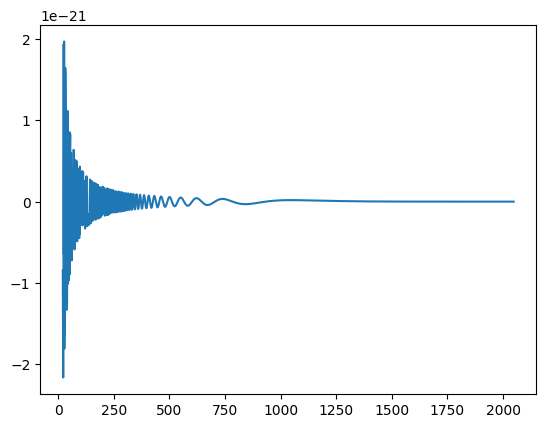

In [8]:
plt.plot(frequencies,hp)
plt.show()

In [9]:
import mlgw_bns, jax, jax.numpy as jnp
from mlgw_bns.jax_predict import model_to_jax_predict

model = mlgw_bns.Model.default()
predict = model_to_jax_predict(model)

# parâmetros: (n_amostras, 5) → [mass_ratio, lambda_1, lambda_2, chi_1, chi_2]
params = jnp.array([[1.5, 300.0, 300.0, 0.1, 0.1]])

residuals     = predict(params)            # chamada normal
residuals_jit = jax.jit(predict)(params)  # JIT compilado
grad_fn       = jax.grad(lambda p: predict(p).sum())(params)  # diferenciável
batch_fn      = jax.vmap(predict)          # batchable

In [10]:
residuals

Array([[-5.51226456e-03, -5.51699364e-03, -5.52574605e-03, ...,
         1.48646846e+01,  1.57525431e+01,  1.63992965e+01]],      dtype=float64)

In [ ]:
model(params)

In [1]:
import mlgw_bns

/workspaces/mlgw_bns/mlgw_bns/model.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import jax
import jax.numpy as jnp

In [3]:
from mlgw_bns import ParametersWithExtrinsic
import numpy as np
from mlgw_bns import Model
from mlgw_bns.jax_predict import model_to_jax_waveform

In [4]:
from mlgw_bns.jax_predict import (
    model_to_jax_predict,      # → residuals NN+PCA na grade reduzida
    model_to_jax_waveform_ds,  # → (amp, phi) na grade amostrada
    model_to_jax_waveform,     # → (hp, hc) em frequências arbitrárias
)

model = mlgw_bns.Model.default()
predict = jax.jit(model_to_jax_waveform(model))

# params = [q, λ₁, λ₂, χ₁, χ₂], q >= 1
params_jax    = jnp.array([1.1, 300.0, 300.0, 0.1, 0.1])
freqs_jax     = jnp.linspace(20., 2048., num=2000)
total_mass    = jnp.array(2.8)   # massa total do sistema binário (M☉)
distance_mpc  = jnp.array(100.0) # distância de luminosidade (Mpc)
inclination   = jnp.array(0.0)   # ângulo de inclinação (rad)

hp, hc = predict(params_jax, freqs_jax, total_mass, distance_mpc, inclination)


In [5]:
import numpy as np
from mlgw_bns import ParametersWithExtrinsic

# Parâmetros compartilhados
q, lam1, lam2, chi1, chi2 = 1.1, 300.0, 300.0, 0.1, 0.1
M_tot, dist, iota = 2.8, 100.0, 0.8
freqs_np = np.linspace(20.0, 2048.0, num=2000)

# --- JAX ---
params_jax   = jnp.array([q, lam1, lam2, chi1, chi2])
freqs_jax    = jnp.array(freqs_np)
hp_jax, hc_jax = predict(
    params_jax,
    freqs_jax,
    jnp.array(M_tot),
    jnp.array(dist),
    jnp.array(iota),
)

# --- Original (numpy/numba) ---
p_ext = ParametersWithExtrinsic(
    mass_ratio=q, lambda_1=lam1, lambda_2=lam2,
    chi_1=chi1, chi_2=chi2,
    distance_mpc=dist, inclination=iota, total_mass=M_tot,
)
hp_ref, hc_ref = model.predict(freqs_np, p_ext)


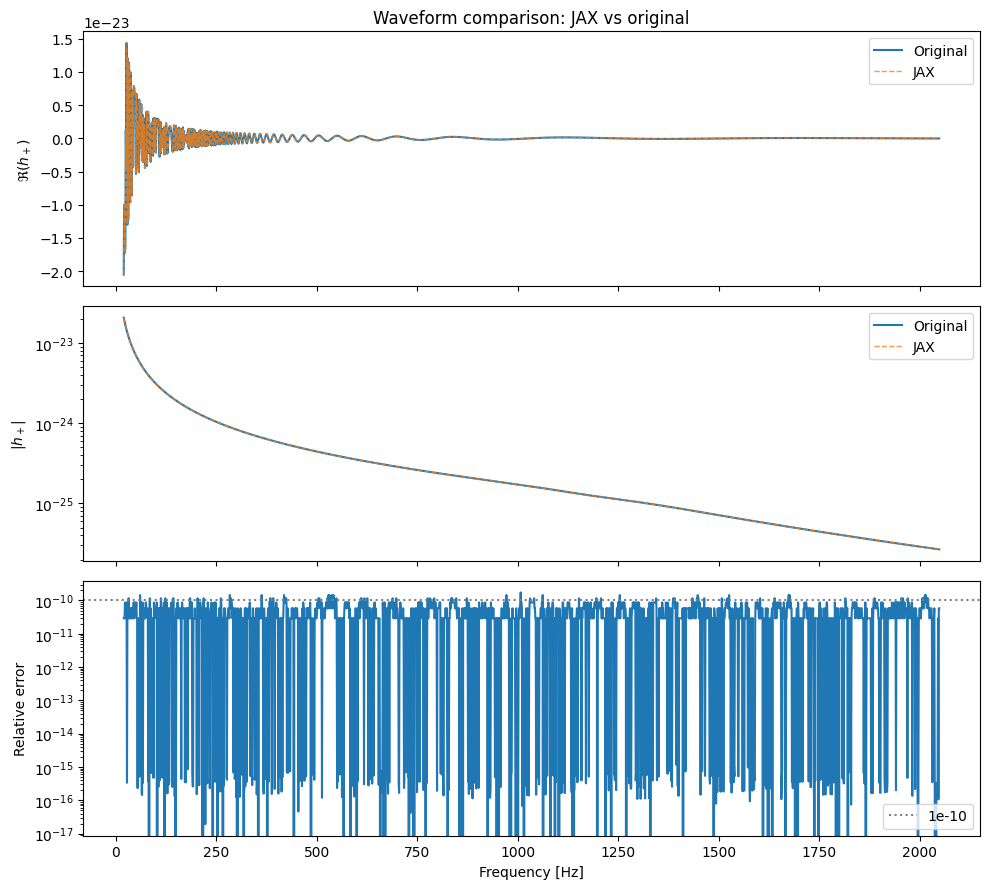

Max relative error hp: 1.75e-10
Max absolute error hp: 1.52e-33


In [6]:
import matplotlib.pyplot as plt

hp_j = np.array(hp_jax)
hp_r = np.array(hp_ref)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# -- Waveform real part --
axes[0].plot(freqs_np, hp_r.real, label="Original", lw=1.5)
axes[0].plot(freqs_np, hp_j.real, "--", label="JAX", lw=1, alpha=0.8)
axes[0].set_ylabel(r"$\Re(h_+)$")
axes[0].legend()
axes[0].set_title("Waveform comparison: JAX vs original")

# -- Amplitude comparison --
amp_r = np.abs(hp_r)
amp_j = np.abs(hp_j)
axes[1].plot(freqs_np, amp_r, label="Original", lw=1.5)
axes[1].plot(freqs_np, amp_j, "--", label="JAX", lw=1, alpha=0.8)
axes[1].set_ylabel(r"$|h_+|$")
axes[1].set_yscale("log")
axes[1].legend()

# -- Relative error --
rel_err = np.abs(hp_j - hp_r) / (np.abs(hp_r) + 1e-60)
axes[2].semilogy(freqs_np, rel_err)
axes[2].set_ylabel("Relative error")
axes[2].set_xlabel("Frequency [Hz]")
axes[2].axhline(1e-10, color="gray", ls=":", label="1e-10")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Max relative error hp: {rel_err.max():.2e}")
print(f"Max absolute error hp: {np.abs(hp_j - hp_r).max():.2e}")


In [7]:
import timeit

# Garantir que o JIT já compilou antes de medir
_ = predict(params_jax, freqs_jax, jnp.array(M_tot), jnp.array(dist), jnp.array(iota))

# --- Original (numpy/numba) ---
t_orig = timeit.timeit(
    lambda: model.predict(freqs_np, p_ext),
    number=200,
) / 200

# --- JAX JIT (single call, com block_until_ready para sincronizar) ---
def jax_call():
    hp, hc = predict(params_jax, freqs_jax, jnp.array(M_tot), jnp.array(dist), jnp.array(iota))
    hp.block_until_ready()

t_jax = timeit.timeit(jax_call, number=200) / 200

print(f"Original (numpy/numba): {t_orig*1e3:.3f} ms")
print(f"JAX JIT (single):       {t_jax*1e3:.3f} ms")
print(f"Speedup:                {t_orig/t_jax:.1f}x")


Original (numpy/numba): 3.369 ms
JAX JIT (single):       1.412 ms
Speedup:                2.4x


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Parâmetros comuns
_tm = jnp.array(M_tot)
_dm = jnp.array(dist)
_io = jnp.array(iota)

rng = np.random.default_rng(42)
base = np.array([q, lam1, lam2, chi1, chi2])
N_seq = 1000
all_params_np  = base + rng.uniform(-0.05, 0.05, size=(N_seq, 5)) * base
all_params_jnp = jnp.array(all_params_np)

# ── Gráfico 1: batch (original loop vs JAX vmap) ─────────────────────────────
batch_sizes  = [1, 2, 4, 8, 16, 32, 64, 128, 256]
t_jax_vmap   = []
t_orig_batch = []

for N in batch_sizes:
    batch = all_params_jnp[:N]

    vmapped = jax.jit(jax.vmap(lambda p: predict(p, freqs_jax, _tm, _dm, _io)))
    vmapped(batch)  # warm-up
    t = timeit.timeit(lambda: vmapped(batch)[0].block_until_ready(), number=100) / 100
    t_jax_vmap.append(t * 1e3)

    params_list = [
        ParametersWithExtrinsic(
            mass_ratio=float(all_params_np[i, 0]), lambda_1=float(all_params_np[i, 1]),
            lambda_2=float(all_params_np[i, 2]), chi_1=float(all_params_np[i, 3]),
            chi_2=float(all_params_np[i, 4]),
            distance_mpc=dist, inclination=iota, total_mass=M_tot,
        )
        for i in range(N)
    ]
    t = timeit.timeit(
        lambda: [model.predict(freqs_np, p) for p in params_list],
        number=50,
    ) / 50
    t_orig_batch.append(t * 1e3)
    print(f"batch N={N:3d}  orig={t_orig_batch[-1]:.1f} ms  jax_vmap={t_jax_vmap[-1]:.1f} ms")

# ── Gráfico 2: tempo acumulado para 1000 waveforms sequenciais (sem batch) ────
print("\nMedindo 1000 chamadas sequenciais...")

t_orig_seq = []
for i in range(N_seq):
    p = ParametersWithExtrinsic(
        mass_ratio=float(all_params_np[i, 0]), lambda_1=float(all_params_np[i, 1]),
        lambda_2=float(all_params_np[i, 2]), chi_1=float(all_params_np[i, 3]),
        chi_2=float(all_params_np[i, 4]),
        distance_mpc=dist, inclination=iota, total_mass=M_tot,
    )
    t0 = time.perf_counter()
    model.predict(freqs_np, p)
    t_orig_seq.append(time.perf_counter() - t0)

t_jax_seq = []
for i in range(N_seq):
    p = all_params_jnp[i]
    t0 = time.perf_counter()
    predict(p, freqs_jax, _tm, _dm, _io)[0].block_until_ready()
    t_jax_seq.append(time.perf_counter() - t0)

cum_orig = np.cumsum(t_orig_seq) * 1e3
cum_jax  = np.cumsum(t_jax_seq)  * 1e3
print(f"Total original: {cum_orig[-1]:.0f} ms | Total JAX: {cum_jax[-1]:.0f} ms | Speedup: {cum_orig[-1]/cum_jax[-1]:.1f}x")


batch N=  1  orig=4.9 ms  jax_vmap=0.8 ms
batch N=  2  orig=7.7 ms  jax_vmap=1.6 ms
batch N=  4  orig=24.7 ms  jax_vmap=4.3 ms
batch N=  8  orig=28.5 ms  jax_vmap=5.1 ms
batch N= 16  orig=62.2 ms  jax_vmap=10.1 ms
batch N= 32  orig=125.0 ms  jax_vmap=18.8 ms
batch N= 64  orig=242.8 ms  jax_vmap=39.6 ms
batch N=128  orig=462.4 ms  jax_vmap=74.6 ms
batch N=256  orig=869.1 ms  jax_vmap=155.9 ms

Medindo 1000 chamadas sequenciais...
Total original: 3631 ms | Total JAX: 918 ms | Speedup: 4.0x


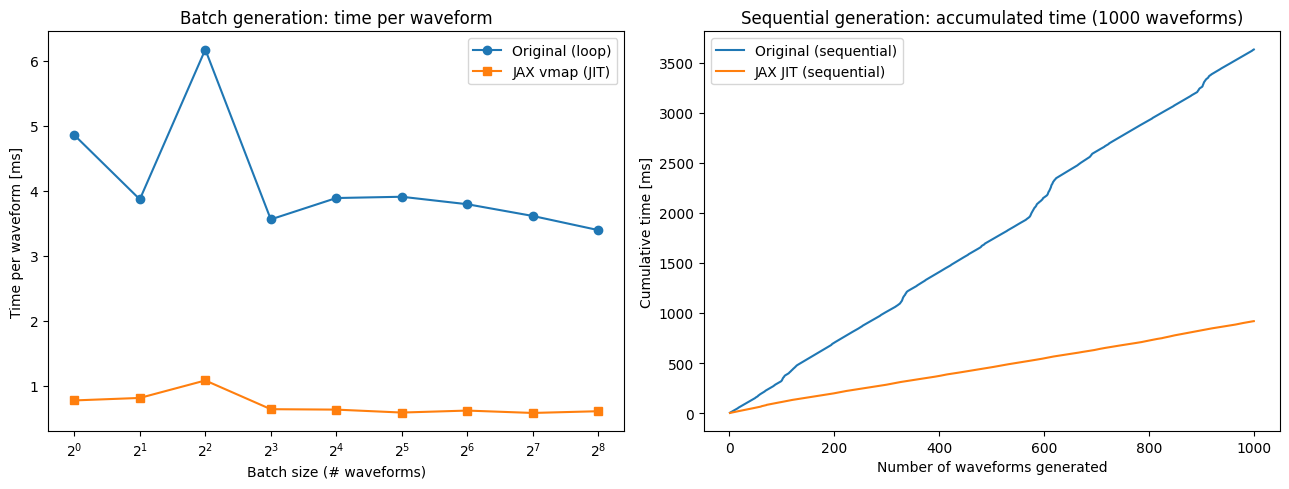

In [13]:
bs = np.array(batch_sizes)
t_orig_arr = np.array(t_orig_batch)
t_vmap_arr = np.array(t_jax_vmap)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Gráfico 1: tempo por waveform em batch ────────────────────────────────────
ax1.plot(bs, t_orig_arr / bs, "o-", label="Original (loop)")
ax1.plot(bs, t_vmap_arr / bs, "s-", label="JAX vmap (JIT)")
ax1.set_xlabel("Batch size (# waveforms)")
ax1.set_ylabel("Time per waveform [ms]")
ax1.set_title("Batch generation: time per waveform")
ax1.set_xscale("log", base=2)
ax1.legend()

# ── Gráfico 2: tempo acumulado para 1000 waveforms sequenciais ────────────────
wfm_idx = np.arange(1, N_seq + 1)
ax2.plot(wfm_idx, cum_orig, label="Original (sequential)")
ax2.plot(wfm_idx, cum_jax,  label="JAX JIT (sequential)")
ax2.set_xlabel("Number of waveforms generated")
ax2.set_ylabel("Cumulative time [ms]")
ax2.set_title("Sequential generation: accumulated time (1000 waveforms)")
ax2.legend()

plt.tight_layout()
plt.show()


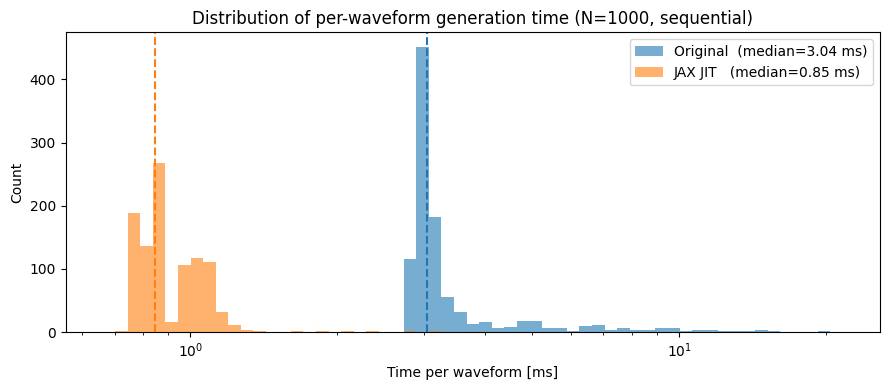

In [15]:
t_orig_ms = np.array(t_orig_seq) * 1e3
t_jax_ms  = np.array(t_jax_seq)  * 1e3

fig, ax = plt.subplots(figsize=(9, 4))

log_min = np.log10(min(t_orig_ms.min(), t_jax_ms.min()) * 0.9)
log_max = np.log10(max(t_orig_ms.max(), t_jax_ms.max()) * 1.1)
bins = np.logspace(log_min, log_max, 60)

ax.hist(t_orig_ms, bins=bins, alpha=0.6, label=f"Original  (median={np.median(t_orig_ms):.2f} ms)")
ax.hist(t_jax_ms,  bins=bins, alpha=0.6, label=f"JAX JIT   (median={np.median(t_jax_ms):.2f} ms)")

ax.axvline(np.median(t_orig_ms), color="C0", ls="--", lw=1.5)
ax.axvline(np.median(t_jax_ms),  color="C1", ls="--", lw=1.5)

ax.set_xscale("log")
ax.set_xlabel("Time per waveform [ms]")
ax.set_ylabel("Count")
ax.set_title("Distribution of per-waveform generation time (N=1000, sequential)")
ax.legend()
plt.tight_layout()
plt.show()
